In [57]:
# ====================================================
# 머신러닝 실습 퀴즈
# 주제 : 제조 공정 품질 이상 분류
# ====================================================

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fontTools.merge import cmap
from matplotlib.pyplot import pie
from numpy.distutils.mingw32ccompiler import rc_name

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline # 전처리, feature 선택, 모델 학습을 하나의 흐름으로 묶어 줌
from sklearn.impute import SimpleImputer # 결측치를 (중앙값, 최빈값 등)으로 채워줌

from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, mutual_info_classif, SelectFromModel

# 평가 지표
from sklearn.metrics import (
 accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
)

# 분석 모델
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier # 랜덤포레스트 ,그래디언트 부스팅 앙상블 ㄴ모델
from sklearn.inspection import permutation_importance # 학습된 모델에서 feature 중요도를 해석할 때 사용

np.random.seed(42)

C:\Users\human\AppData\Local\Temp\ipykernel_9064\4172848764.py:6: DeprecationWarning: 

  `numpy.distutils` is deprecated since NumPy 1.23.0, as a result
  of the deprecation of `distutils` itself. It will be removed for
  Python >= 3.12. For older Python versions it will remain present.
  It is recommended to use `setuptools < 60.0` for those Python versions.
  For more details, see:
    https://numpy.org/devdocs/reference/distutils_status_migration.html 


  from numpy.distutils.mingw32ccompiler import rc_name


In [59]:
# ====================================================
# 1. 가상 제조 데이터 생성
# ====================================================

n_samples = 1500  # 샘플 수를 1500개로 설정

# 평균 75, 표준편차 10인 분포를 따르는 정규분포의 데이터로 생성
temperature = np.random.normal(75, 10, n_samples)       # 공정 온도
pressure = np.random.normal(30, 5, n_samples)           # 압력
vibration = np.random.normal(4.5, 1.2, n_samples)       # 진동
humidity = np.random.normal(45, 12, n_samples)          # 습도
torque = np.random.normal(220, 35, n_samples)           # 모터의 출력 토크 (힘)
speed = np.random.normal(1500, 250, n_samples)          # 모터 회전속도
operator_experience = np.random.normal(5, 2, n_samples) # 작업자 숙련도(년수)

# 장비 타입을 A, B, C 중 하나로 생성
machine_type = np.random.choice(['A', 'B', 'C'], n_samples, p=[0.4, 0.35, 0.25])
# 근무조를 Day, Night 중 하나로 생성
shift = np.random.choice(['day', 'night'], n_samples, p=[0.6, 0.4])
# 재료 등급을 low, medium, high 중 하나로 생성
material_grade = np.random.choice(['low', 'medium', 'high'], n_samples, p=[0.2, 0.5, 0.3])

# 품질 불량 기준 정의
risk_score = (
    0.04 * (temperature - 75) +          # 온도가 기준보다 높을수록 위험 증가
    0.07 * (pressure - 30) +             # 압력이 기준보다 높을수록 위험 증가
    0.35 * (vibration - 4.5) +           # 진동은 비교적 큰 영향을 주도록 가중치를 크게 설정
    0.015 * (humidity - 45) +            # 습도도 일부 영향
    0.01 * (torque - 220) -              # 토크 증가 영향
    0.003 * (speed - 1500) -             # 속도가 증가하면 약간 안정화되도록 음수 가중치
    0.15 * (operator_experience - 5)     # 숙련도가 높을수록 불량 감소
)

# 범주형 영향도
# 특정 장비 타입, 야간 근무, 저등급 재료일때 위험 점수를 추가하기 위한 기준
risk_score += np.where(machine_type == 'C', 0.45, 0.0)
risk_score += np.where(shift == 'night', 0.35, 0.0)
risk_score += np.where(material_grade == 'low', 0.50, 0.0)
risk_score += np.where(material_grade == 'high', -0.20, 0.0)

# 비선형/상호작용 영향 가중치 (단일 변수 뿐만 아니라, 다변량의 상호작용도 위험에 영향을 주도록 설정)
risk_score += 0.0008 * (temperature * vibration)
risk_score += 0.0005 * (pressure * humidity)

# 온도가 매우 높고 진동도 높은 경우 추가적인 위험ㅇ르 크게 부여하기 위한 기준
risk_score += np.where((temperature > 90) & (vibration > 6) , 1.0, 0.0)


# 리스크 스코어를 확률로 변환.
# sigmoid로 확률화 (risk score 를 0~1 사이의 확률로 변환
prob = 1/ (1+ np.exp(-risk_score))

# 확률에 따라 0 또는 1 의 실제 레이블을 생성 ( 1은 불량, 0은 정상)
target = np.random.binomial(1, prob)

# 생성한 모든 변수를 데이터프레임으로 합침
df = pd.DataFrame(
 {
     'temperature': temperature,
     'pressure': pressure,
     'vibration': vibration,
     'humidity': humidity,
     'torque': torque,
     'speed': speed,
     'operator_experience': operator_experience,
     'machine_type': machine_type,
     'shift': shift,
     'material_grade': material_grade,
     'defect': target
 }
)



In [60]:
df

,temperature,pressure,vibration,humidity,torque,speed,operator_experience,machine_type,shift,material_grade,defect
0,79.967142,33.891805,2.210631,33.494659,181.007152,1931.423448,6.530804,B,day,medium,1
1,73.617357,27.244071,3.467538,28.769896,197.917421,1530.461116,7.146825,B,day,medium,0
2,81.476885,25.909006,4.003673,25.996939,187.027894,1688.354368,5.997380,B,day,medium,0
3,90.230299,29.983128,6.765225,49.955987,200.820146,1524.956579,1.115005,C,night,low,1
4,72.658466,29.149077,5.167864,42.431188,212.504739,1333.166655,4.689155,C,night,medium,1
...,...,...,...,...,...,...,...,...,...,...,...
1495,95.060929,30.387403,6.512853,47.057632,202.490864,1525.407513,4.478783,B,night,high,1
1496,95.615036,31.288763,3.533794,58.831777,201.935918,1791.804433,2.025251,C,day,high,1
1497,87.083662,23.791197,5.792218,30.391154,294.359468,1897.111794,5.174410,C,night,high,1
1498,85.240625,31.670882,1.896387,50.615405,122.916477,1328.753205,7.494607,C,day,medium,0


In [61]:
# ====================================================
# 2. 결측치 삽입 (실습 난이도 향상)
# ====================================================

# 수치형 컬럼 일부에도 5% 정도 결측치를 넣어 현실 데이터처럼 모사

for col in ['temperature', 'pressure', 'vibration', 'humidity', 'torque']:
    idx = np.random.choice(df.index, size = int(0.05* n_samples), replace=False)
    df.loc[idx, col] = np.nan

for col in ['machine_type','material_grade']:
    idx =np.random.choice(df.index, size = int(0.03*n_samples), replace=False)
    df.loc[idx, col] = np.nan


In [62]:
# ====================================================
# 3. Feature Engineering
# ====================================================
# 도메인 기반 feature를 생성

# 온도와 압력 비율값 생성 (문모가 0 되는 문제 막기 위해 1e-6 더해줌)
df['temp_pressure_ratio'] = df['temperature'] / (df['pressure'] + 1e-6)

# 진동과 토크의 곱을 만들어서 기계적 상호작용을 반영
df['vibration_torque_interaction'] = df['vibration'] * df['torque']

# 에너지 지표로서, 토크와 속도의 비율 생성
df['energy_proxy'] = df['torque'] * df['speed']

# 온도와 습도의 차이를 만들어서 환경적 스트레스 지표 활용
df['temp_humidity_gap'] = df['temperature'] - df['humidity']

# 압력과 진동이 크고, 작업자 숙련도가 낮으면 stress index가 커진다
df['stress_index'] = df['pressure'] * df['vibration'] / (df['operator_experience'] + 1)

In [63]:
# 메인 유틸리티에서 전기/유량/압력 등을 제공해줌. 메인유틸리티는 각 설비에 연결되어 있는데,
# 이런 것들이 제대로 공급이 잘 되지 않으면, 설비가 제대로 돌지 않는다. 그 레시피 값에 맞춰 동작을 못 함.
# 전기 -> 모터 x // 유량, 압력 -> 실린더, 프레스 x //
# 이런 것들도 HEALTH INDEX 등으로 만들어 줘야 함.
# 현장에서는 설비에서 일어나는 현상만 보고, 유틸리티 데이터들을 연결시켜서 봐야하고 그것으로 HEALTH INDEX 지표를 만들어 줘야 함. 영향도 지표를 만들어야 하고 ,피쳐엔지니어링 지표를 찾고 만들 때 고려해야할 사항임.

In [64]:
# ====================================================
# 4. 데이터 확인
# ====================================================

# 구분선 출력
print("="*50)

# 상위 5개 행을 출력해서 데이터 형태 확인
print("데이터 상위 5행")
print(df.head())
print("="*80)
print("\n데이터 정보")
print(df.info())

# 타겟 클래스 비율 확인
print("\n클래스 분포")
print(df['defect'].value_counts(normalize=True))

데이터 상위 5행
   temperature   pressure  vibration   humidity      torque        speed  \
0    79.967142  33.891805   2.210631        NaN  181.007152  1931.423448   
1    73.617357  27.244071   3.467538  28.769896  197.917421  1530.461116   
2    81.476885  25.909006   4.003673  25.996939  187.027894  1688.354368   
3    90.230299  29.983128   6.765225  49.955987  200.820146  1524.956579   
4          NaN  29.149077   5.167864  42.431188  212.504739  1333.166655   

   operator_experience machine_type  shift material_grade  defect  \
0             6.530804          NaN    day         medium       1   
1             7.146825            B    day         medium       0   
2             5.997380            B    day         medium       0   
3             1.115005            C  night            low       1   
4             4.689155            C  night         medium       1   

   temp_pressure_ratio  vibration_torque_interaction   energy_proxy  \
0             2.359483                    400.1

In [65]:
df.columns

Index(['temperature', 'pressure', 'vibration', 'humidity', 'torque', 'speed',
       'operator_experience', 'machine_type', 'shift', 'material_grade',
       'defect', 'temp_pressure_ratio', 'vibration_torque_interaction',
       'energy_proxy', 'temp_humidity_gap', 'stress_index'],
      dtype='object')

In [66]:
# ====================================================
# 5. 입력 / 타겟 분리
# ====================================================
#입력 변수 x는 defect 컬럼 제외한 나머지컬럼
X = df.drop(columns=['defect'])

# 타겟 y 는 defect 컬럼
y = df['defect']

# 수치형 컬럼명 별로 리스트로 관리
numeric_features = [
    'temperature', 'pressure', 'vibration', 'humidity', 'torque', 'speed',
       'operator_experience', 'temp_pressure_ratio', 'vibration_torque_interaction',
       'energy_proxy', 'temp_humidity_gap', 'stress_index'
]

# 범주형 컬럼도 별도로 리스트로 관리
categorical_features = ['machine_type', 'shift','material_grade']

In [67]:
# ====================================================
# 6. 학습/테스트 분리
# ====================================================

# 학습데이터 80%, 테스트 데이터 20% 나눔
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    stratify=y, # 클래스 비율이 80%/20% 동일한 비율로 적용
    random_state=42
)

In [68]:
# ====================================================
# 7. 전처리 파이프라인
# ====================================================

# 수치형 데이처 처리 파이프라인
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')), # 수치형 결측치는 중앙값으로 치환
        ('scaler', StandardScaler()) # 수치형 데이터를 평균0, 표준편차 1로 스케일링
    ]
)

# 범주형 데이터 처리 파이프라인
categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')), #범주형 결측치는 최빈값으로 치환
        ('onehot', OneHotEncoder(handle_unknown='ignore'))  # 범주형은 원-핫 인코딩 처리 # 처음보는 범주 나와도 스킵. (예외처리.)
    ]
)

# ColumnTransformer 로 수치형 /범주형 서로 다른 전처리 적용
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

In [69]:
# ====================================================
# 8. 모델 파이프라인 정의
# ====================================================

# 여러 모델을 딕셔너리 형태로 정의

models = {
    # Logistic Regression 은 선형 기반 분류 모델
    'LogisticRegression' : LogisticRegression(max_iter=2000),

    # RandomForest는 여러 트리를 앙상블한 모델
    'RandomForest': RandomForestClassifier(
        n_estimators=250,
        max_depth=8,
        min_samples_split=10, # 노드 분할 최소 샘플 수
        random_state=42
    ),
    # 그라디언트 부스팅은 순차적으로 오차를 줄여가는 부스팅 모델
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=150, # 약한 학습기 개수
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

# 각 모델 전체 파이프라인을 저장할 딕셔너리 생성
pipelines ={}

# 각 모델마다 전처리 + feature 선택 + 분류기를 하나의 파이프라인으로 생성
for model_name, model in models.items():
    pipelines[model_name] = Pipeline(
        steps=[
            ('preprocessor', preprocessor), # 먼저 전처리 수행
            ('feature_selection', SelectKBest(score_func=mutual_info_classif, k =15)), #상위 15개 feature 선택
            ('classifier',model) # 마지막 분류 모델 적용
        ]
    )

In [70]:
# ====================================================
# 9. 교차검증 성능 비교
# ====================================================

# StratifiedKFold 를 사용해서 클래스 비율을 유지하면서 5등분 교차 검증 진행
cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

# 각 모델의 교차 검증 결과를 저장할 리스트
cv_results = []

# 모델 별 성능 비교
for model_name , pipe in pipelines.items():
    # cross_val_score 로 학습데이터에서 F1-Score 기준 교차검증 수행
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)

    # 결과를 cv_results 리스트에 딕셔너리로 저장
    cv_results.append(
        {
            'model': model_name,
            'cv_f1_mean': scores.mean(),
            'cv_f1_std': scores.std()
        }
    )

# 교차검증 결과를 데이터프레임으로 만들고, 평균 F1 기준 내림차순 정렬
cv_df = pd.DataFrame(cv_results).sort_values(by = 'cv_f1_mean',ascending=False )

#  결과 출력
print("\n"  + "=" * 80)
print("교차검증 결과 (F1 기준)")
print(cv_df)
print("="*80)

# 가장 성능 좋은 모델 이름 선택
best_model_name = cv_df.iloc[0]['model']

# 선택된 해당 모델의 파이프라인을 최종 모델로 선정
best_pipeline = pipelines[best_model_name]

# 선택된 최종 모델 출력
print(f"\n선택된 최종 모델 : {best_model_name}")


교차검증 결과 (F1 기준)
                model  cv_f1_mean  cv_f1_std
0  LogisticRegression    0.837825   0.006503
1        RandomForest    0.834438   0.004478
2    GradientBoosting    0.828646   0.007876

선택된 최종 모델 : LogisticRegression


파이참이나 비쥬얼스튜디오 에서 할 때는 전부 클래스나 함수로 묶어서 모듈화 해줘야 함.

In [71]:
# ====================================================
# 10. 최종 모델 학습
# ====================================================

# 선택은 최종 파이프라인을 전체 학습 데이터(80%)에 대해 학습 시킴
best_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [72]:
# ====================================================
# 11. 테스트 데이터 예측
# ====================================================

# 테스트 데이터 (20%) 대해 최종 클래스 예측값(0/1) 을 예측
y_pred = best_pipeline.predict(X_test)

# 테스트데이터에 대해 클래스 1 (불량)일 확률을 구함
y_proba = best_pipeline.predict_proba(X_test)[:,1]

In [73]:
# ====================================================
# 12. 모델 평가
# ====================================================


# 정확도 계산
acc =accuracy_score(y_test, y_pred)
# 정밀도 계산
prec = precision_score(y_test, y_pred)
# 재현율 계산
rec = recall_score(y_test, y_pred)
# F1-Score 계산
f1 = f1_score(y_test, y_pred)
# ROC-AU 계산
roc_auc = roc_auc_score(y_test, y_proba)

# 평가 결과 출력
print("\n테스트 성능")
print(f"Accuracy : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC_AUC : {roc_auc:.4f}")

# 클래스 별 precision, recall, f1 등을 상세히 출력
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# Confusion Matrix 계산
cm = confusion_matrix(y_test, y_pred)

# Confusion Matrix 결과 출력
print("Confusion Matrix")
print(cm)

# 분류모델에서 mse, rmse 쓰면 욕 바가지로 먹는다~
# 회귀모델 acc




테스트 성능
Accuracy : 0.7500
Precision : 0.7957
Recall : 0.8738
F1-score : 0.8330
ROC_AUC : 0.7652

Classification Report
              precision    recall  f1-score   support

           0       0.58      0.44      0.50        86
           1       0.80      0.87      0.83       214

    accuracy                           0.75       300
   macro avg       0.69      0.66      0.67       300
weighted avg       0.74      0.75      0.74       300

Confusion Matrix
[[ 38  48]
 [ 27 187]]


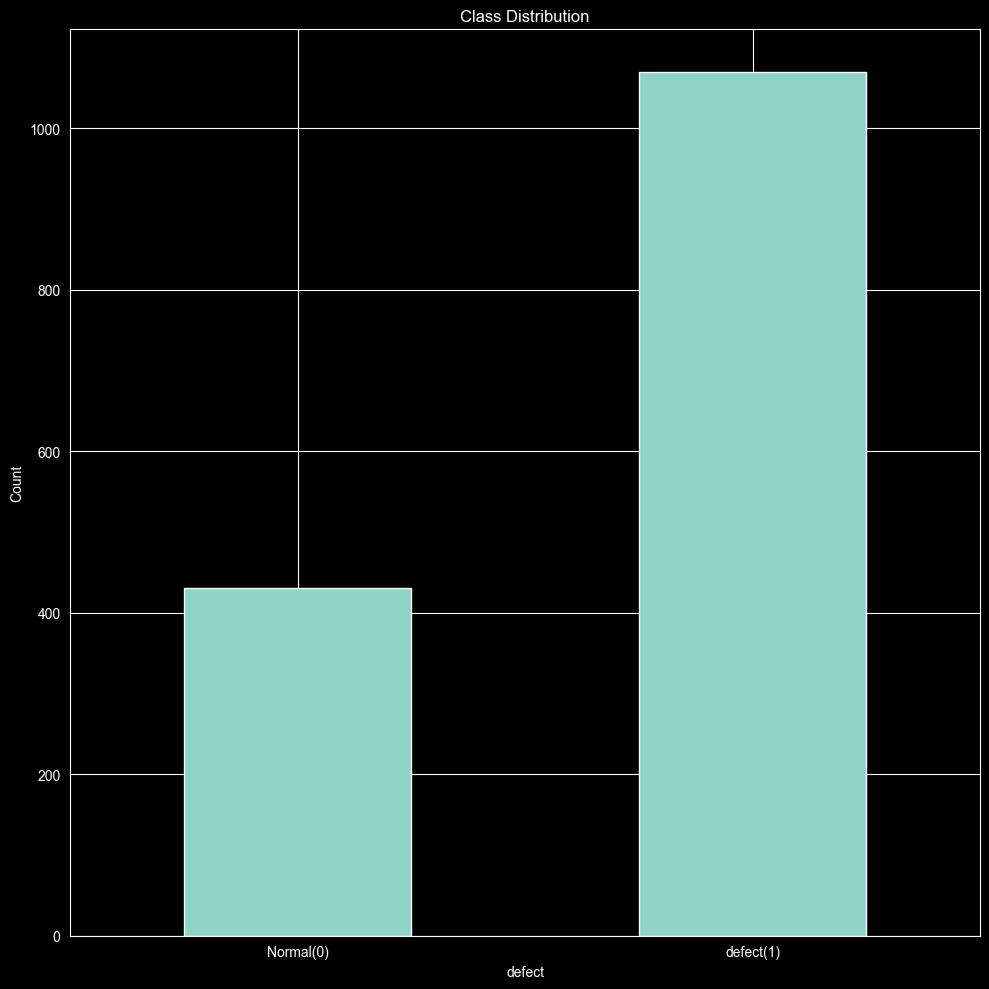

In [74]:
# ====================================================
# 13. 시각화 1 - 클래스 분포
# ====================================================

plt.figure(figsize=(10,10)  )
df['defect'].value_counts().sort_index().plot(kind='bar') # 클래스 : DEFECT 0 or 1

# x 축 눈금 라벨 지정
plt.xticks([0,1],['Normal(0)',"defect(1)"],rotation=0)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

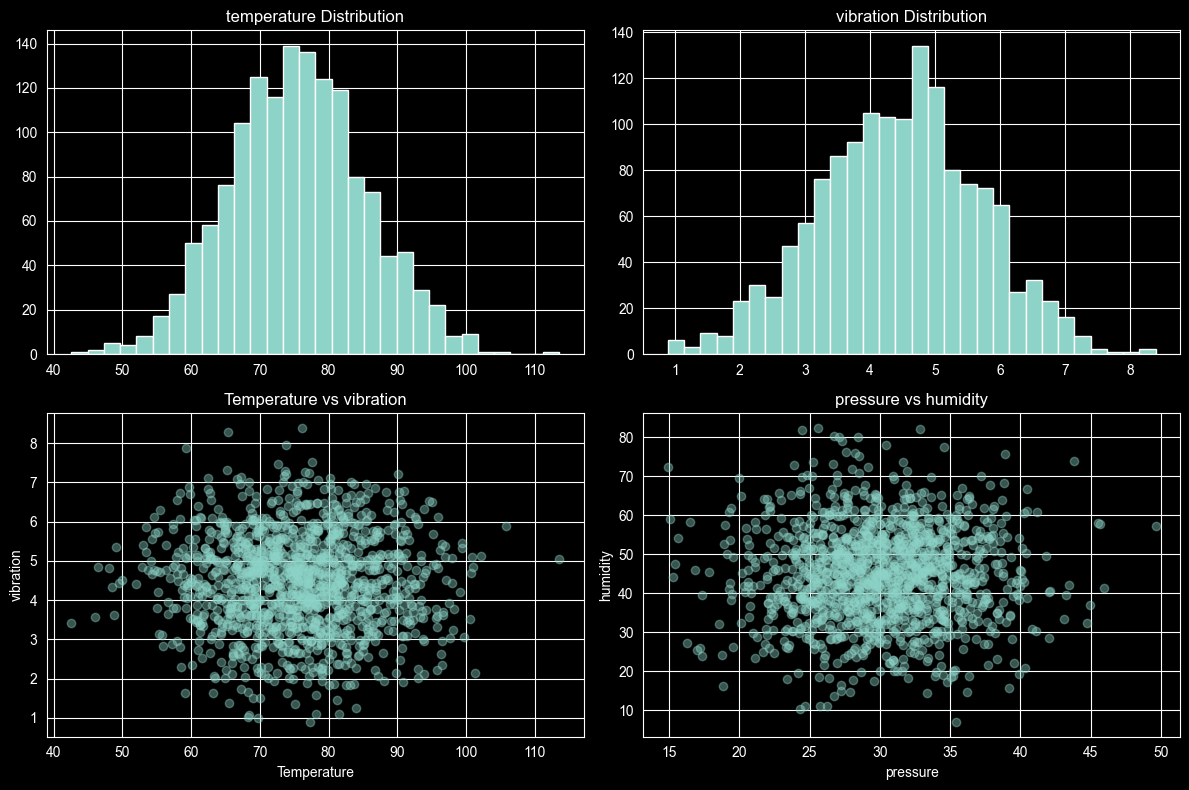

In [75]:
# ====================================================
# 14. 주요 변수 분포
# ====================================================

# 2행 2열 subplot 생성
fig, axes = plt.subplots(2,2, figsize=(12,8) )

# temperature 히스토그램
axes[0,0].hist(df['temperature'].dropna(),bins=30)
axes[0,0].set_title("temperature Distribution")

# vibration 히스토그램
axes[0,1].hist(df['vibration'].dropna(),bins=30)
axes[0,1].set_title("vibration Distribution")

# temperature 와 vibration 산점도
axes[1,0].scatter(df['temperature'], df['vibration'],alpha = 0.4)
axes[1,0].set_title("Temperature vs vibration")
axes[1,0].set_xlabel("Temperature")
axes[1,0].set_ylabel("vibration")

# pressure 와 humidity 산점도
axes[1,1].scatter(df['pressure'], df['humidity'],alpha = 0.4)
axes[1,1].set_title("pressure vs humidity")
axes[1,1].set_xlabel("pressure")
axes[1,1].set_ylabel("humidity")


plt.tight_layout()
plt.show()


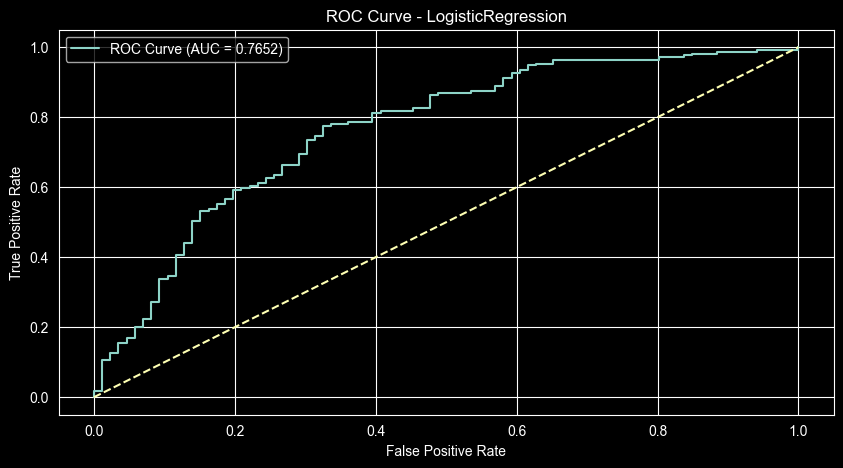

In [76]:
# ====================================================
# 15. 시각화 3 - ROC Curve
# ====================================================
# 가성에 얼마나 강인하냐
# ROC AUC 보면서 판단 할 수 있는 것
# - 기준값 (Threshhold) (
# - 기준값을 광범위 하게 잡으면 불량 놓치는 경우 많아짐.
# - 타이트하게 잡으면 정상도 불량으로 잡는 경우 많아짐.
# Threadshold 를 광범위하게 잡을 거냐 타이트하게 잡을 거냐도 문제임.
# Threadshold 는 표준이 없음.

# ROC curve 계산
fpr, tpr, _ = roc_curve(y_test, y_proba)

# figure 생성
plt.figure(figsize=(10,5) )

#ROC curve 그리기
plt.plot(fpr, tpr, label = f"ROC Curve (AUC = {roc_auc:.4f})")

# 랜덤 분류 기준선
plt.plot([0, 1], [0, 1], linestyle = "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - {best_model_name}")

plt.legend()
#plt.tight_layout()
plt.show()

C:\Users\human\AppData\Local\Temp\ipykernel_9064\3936149454.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


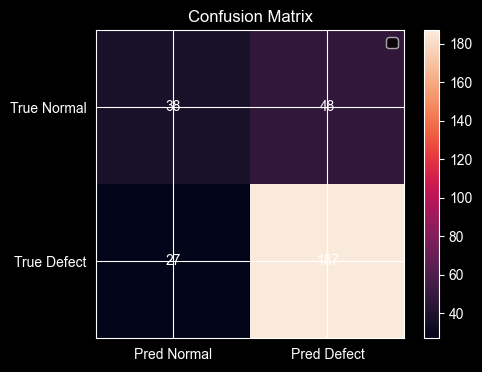

In [77]:
# ====================================================
# 16. 시각화 5 - Confusion Matrix
# ====================================================
plt.figure(figsize=(5,4) )

# Confusion Matrix을 이미지처럼 출력
plt.imshow(cm, interpolation='nearest')

plt.title("Confusion Matrix")
plt.colorbar()

# x 축 눈금 라벨
plt.xticks([0,1], ['Pred Normal', 'Pred Defect'])
# y 축 눈금 라벨
plt.yticks([0,1], ['True Normal', 'True Defect'])

# 셀 안에 실제 숫자 값을 텍스트로 표시
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j,i,cm[i,j],ha = 'center',va = 'center',)

plt.legend()
plt.show()



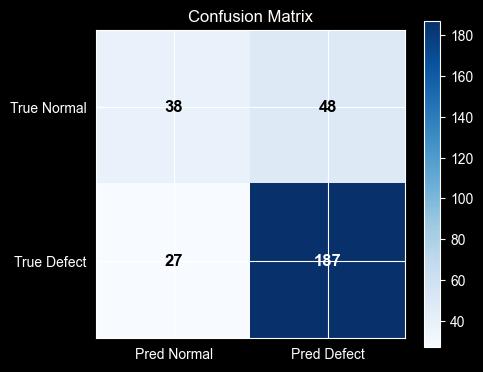

In [78]:
# ====================================================
# 16. 시각화 5 - Confusion Matrix (컬러 최적화)
# ====================================================
plt.figure(figsize=(5, 4))

# 1. 시각적으로 명확한 컬러맵(cmap) 지정 (예: Blues, Viridis)
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title("Confusion Matrix")
plt.colorbar()

# x, y 축 라벨 설정
plt.xticks([0, 1], ['Pred Normal', 'Pred Defect'])
plt.yticks([0, 1], ['True Normal', 'True Defect'])

# 2. 임계값 설정 (배경이 이 값보다 크면 글자를 흰색으로, 작으면 검은색으로)
threshold = cm.max() / 2.

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        # 배경색이 어두우면(값이 크면) 글자를 white, 밝으면 black
        color = "white" if cm[i, j] > threshold else "black"

        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color=color,          # 이 부분이 핵심입니다!
                 fontsize=12,          # 글자 크기도 조금 키워주면 좋습니다.
                 fontweight='bold')    # 굵게 하면 더 잘 보입니다.

# plt.legend() 는 삭제하세요. (Confusion Matrix에는 필요 없습니다)
plt.tight_layout()
plt.show()

상위 중요 feature
                         feature  importance_mean
4                          speed         0.018737
6   vibration_torque_interaction         0.003113
0                    temperature         0.000235
5            operator_experience         0.000000
9                 machine_type_C        -0.000119
3                         torque        -0.000277
8                 machine_type_B        -0.001303
13            material_grade_low        -0.002215
14         material_grade_medium        -0.006522
12           material_grade_high        -0.006679


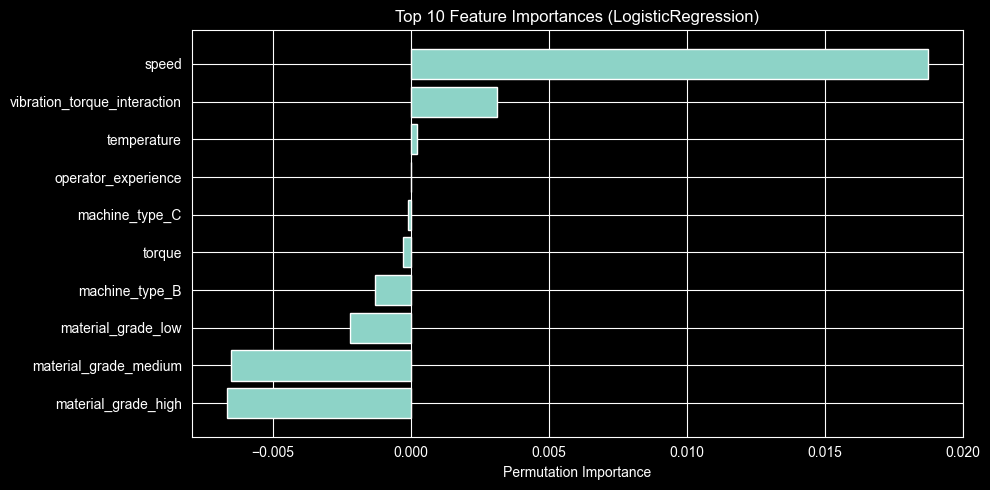

In [79]:
# ====================================================
# 18. 모델 해석 - Feature Importance
# ====================================================

#전처리를 완료한 후, 파이프라인 내부에서 전처리기, feature selector, classifier를 꺼낸다.
preprocessor_fitted = best_pipeline.named_steps['preprocessor']
feature_selector = best_pipeline.named_steps['feature_selection']
classifier =best_pipeline.named_steps['classifier']

# 테스트 데이터 전처리만 먼저 수행
X_test_transformed = preprocessor_fitted.transform(X_test)

# onehot 포함 전체 feature name --> 범주형 원-핫 인코더를 꺼냄
cat_ohe = preprocessor_fitted.named_transformers_['cat'].named_steps['onehot']

cat_feature_names = cat_ohe.get_feature_names_out(categorical_features)

# 전체 feature name = 수치형 feature + onehot 인코딩된 범주형 feature가 됨.
all_feature_names = np.array(numeric_features + list(cat_feature_names))


# SelectKBest 가 선택한 feature 위치를 True/False 마스크로 얻는다.
selected_mask = feature_selector.get_support()

# 선택된 feature 이름만 추출한다.
selected_feature_names = all_feature_names[selected_mask]

#전처리된 테스트 데이터를 feature selector 로 다시 변환한다.
X_test_selected = feature_selector.transform(X_test_transformed)

# 여기가 중요한데,
# feature importance 계산 --> feature 가 영향도 있을 때, F1- Score가 얼마나 떨어지는지를 보고 중요도를 측정
perm_result = permutation_importance(
    classifier, X_test_selected, y_test,
    n_repeats=10,
    random_state=42,
    scoring = 'f1'
)
# permutation_importance 여기서 계산 해주는 거고, 이 작업 하기 위해서 위에 작업들 해줬던 것.

# 중요도 결과를 데이터프레임으로 정리하고 내림차순 정렬
importance_df = pd.DataFrame({
    'feature': selected_feature_names,
    'importance_mean' : perm_result.importances_mean
}).sort_values(by = 'importance_mean', ascending = False)

# 상위 10개 feature 출력
print('상위 중요 feature')
print(importance_df.head(10))

# 중요도 시각화
plt.figure(figsize=(10,5))

#상위 10개를 선택
top_n = 10

# 가로막대그래프는 아래에서 위로 보이므로 뒤집어서 정력
plot_df = importance_df.head(top_n).iloc[::-1]
# 가로 막대그래프
plt.barh(plot_df['feature'], plot_df['importance_mean'])
plt.title(f"Top {top_n} Feature Importances ({best_model_name})")
plt.xlabel("Permutation Importance")
plt.tight_layout()
plt.show()



신규 데이터 예측 결과
   temperature  pressure  vibration machine_type  shift material_grade  \
0           82        31        4.8            A    day         medium   
1           95        40        7.2            C  night            low   
2           68        25        3.5            B    day           high   
3           88        36        6.5            C  night         medium   
4           77        29        4.2            A    day         medium   

   predicted_class predicted_label  defect_probability  
0                1          Defect            0.806595  
1                1          Defect            0.999614  
2                0          Normal            0.230124  
3                1          Defect            0.991144  
4                1          Defect            0.617505  

[최종 해석]
- 최종 선택 모델: LogisticRegression
- 테스트 F1-score: 0.8330
- 테스트 ROC-AUC : 0.7652
- defect_probability가 높을수록 불량 가능성이 높다고 해석할 수 있음
- 중요 feature를 통해 어떤 공정 인자가 품질 이상에 큰 영향을 주는지 파악할 수 있음


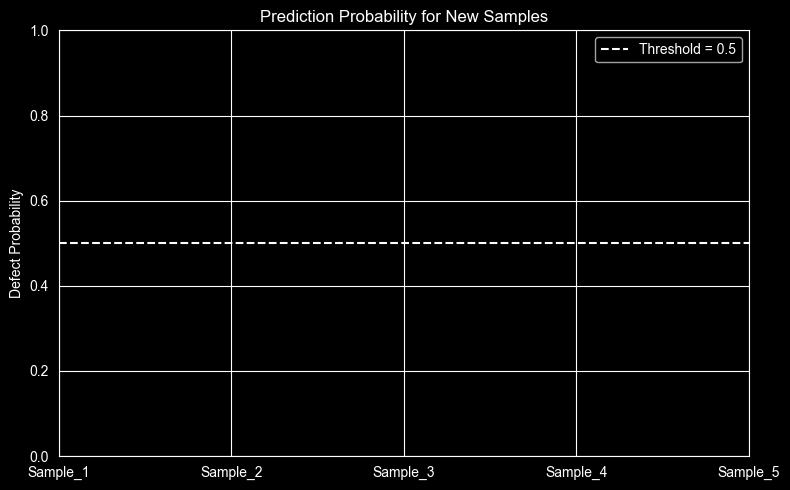

In [80]:
# ====================================================
# 19. 신규 데이터 예측
# ====================================================

# 새로운 샘플 5개를 직접 만듦
new_sample = pd.DataFrame({
    'temperature' : [82,95,68.,88,77],
    'pressure' : [3,140,25,36,29],
    'humidity' : [48,62,38,50,44],
    'torque' : [230,280,190,260,215],
    'speed' : [1480,1320,1580,1400,1510],
    'operator_experience':[5,2,8,3,6],
    'machine_type':['A','C','B','C','A'],
    'shift' : ['day','night','day','night','day'],
    'material_grade': ['medium','low','high','medium','medium']
})

#학습 때 만든 파생변수를 신규 데이터에도 동일하게 만듬

new_sample['temp_pressure_ratio'] = new_sample['temperature'] / (new_sample['pressure'] + 1e-6)
new_sample['vibration_torque_interaction'] = new_sample['vibration'] * new_sample['torque']
new_sample['energy_proxy'] = new_sample['torque'] * new_sample['speed']
new_sample['temp_humidity_gap'] = new_sample['temperature'] - new_sample['humidity']
new_sample['stress_index'] = new_sample['pressure'] * new_sample['vibration'] / (new_sample['operator_experience'] + 1)

# 신규 데이터의 최종 클래스 예측
new_pred = best_pipeline.predict(new_sample)

# 신규 데이터의 불량 확률 예측
new_proba = best_pipeline.predict_proba(new_sample)[:,1]

# 결과를 보기 좋게 정리하기 위해 복사본 생성
result_df = new_sample.copy()

# 예측 클래스를 컬럼으로 추가
result_df['predicted_class']= new_pred

# 불량 확률을 컬럼으로 추가
result_df['defect_probability'] = new_proba

#0
result_df['predicted_label'] = result_df['predicted_class'].map({0:'Normal',1:'Defect'})


# 결과 출력
print("신규 데이터 예측 결과")
print(result_df[[
    'temperature', 'pressure', 'vibration','machine_type'

]])

 'humidity', 'torque', 'speed',
       'operator_experience', 'machine_type', 'shift', 'material_grade',
       'defect', 'temp_pressure_ratio', 'vibration_torque_interaction',
       'energy_proxy', 'temp_humidity_gap', 'stress_index

plt.axhline(0.5, linestyle = '--', label = 'Threshold')

# x 축 라벨을 Sample_0, Sample_1 ..형식으로 표시
plt.xticks(range(len(result_df)), [f'Sample_{i}' for i in range(len(result_df))])
plt.ylabel('Defect Probability')
plt.title("Predicted Probability for New Samples")

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# 최종 결과 해석을 간단히 출력
print("\n[최종 해석]")
print(f" - 최종 선택 모델 : {best_model_name}")
print(f" - 테스트 f1-score : {f1:.4f}")
print(f" - 테스트 ROC-AUC : {roc_auc:.4}")
print(" -  defect_probability가 높을수록 불량 가능성이 높다고 해석할 수 있음")
print(" - 중요 feature를 통해 어떤 공저 인지가 품질 이상에 큰 영향을 주는지 파악할 수 있음.")


신규 데이터 예측 결과
   temperature  pressure  vibration machine_type  shift material_grade  \
0           82        31        4.8            A    day         medium   
1           95        40        7.2            C  night            low   
2           68        25        3.5            B    day           high   
3           88        36        6.5            C  night         medium   
4           77        29        4.2            A    day         medium   

   predicted_class predicted_label  defect_probability  
0                1          Defect            0.806595  
1                1          Defect            0.999614  
2                0          Normal            0.230124  
3                1          Defect            0.991144  
4                1          Defect            0.617505  


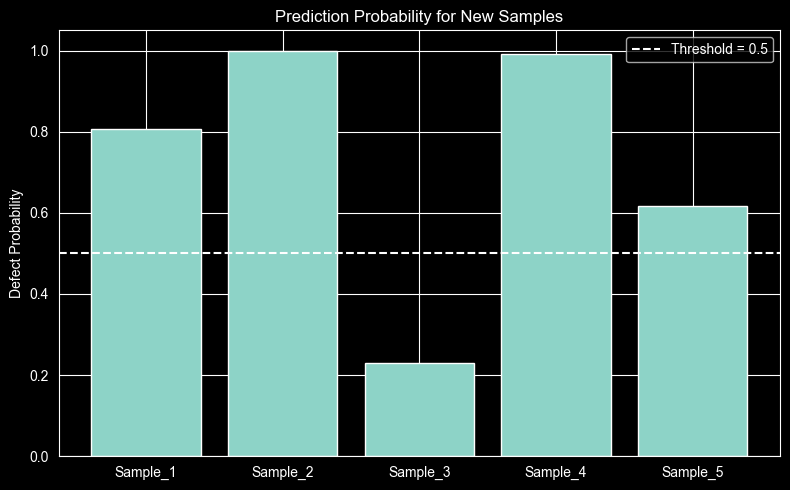


[최종 해석]
- 최종 선택 모델: LogisticRegression
- 테스트 F1-score: 0.8330
- 테스트 ROC-AUC : 0.7652
- defect_probability가 높을수록 불량 가능성이 높다고 해석할 수 있음
- 중요 feature를 통해 어떤 공정 인자가 품질 이상에 큰 영향을 주는지 파악할 수 있음


In [82]:
# ============================================================
# 19. 신규 데이터 예측
# ============================================================

# 새로운 샘플 5개를 직접 만듬
new_samples = pd.DataFrame({
    'temperature': [82, 95, 68, 88, 77],
    'pressure': [31, 40, 25, 36, 29],
    'vibration': [4.8, 7.2, 3.5, 6.5, 4.2],
    'humidity': [48, 62, 38, 50, 44],
    'torque': [230, 280, 190, 260, 215],
    'speed': [1480, 1320, 1580, 1400, 1510],
    'operator_experience': [5, 2, 8, 3, 6],
    'machine_type': ['A', 'C', 'B', 'C', 'A'],
    'shift': ['day', 'night', 'day', 'night', 'day'],
    'material_grade': ['medium', 'low', 'high', 'medium', 'medium']
})

# 학습 때 만든 파생변수를 신규 데이터에도 동일하게 만듬
new_samples['temp_pressure_ratio'] = new_samples['temperature'] / (new_samples['pressure'] + 1e-6)
new_samples['vibration_torque_interaction'] = new_samples['vibration'] * new_samples['torque']
new_samples['energy_proxy'] = new_samples['torque'] * new_samples['speed']
new_samples['temp_humidity_gap'] = new_samples['temperature'] - new_samples['humidity']
new_samples['stress_index'] = (new_samples['pressure'] * new_samples['vibration']) / (new_samples['operator_experience'] + 1)

# 신규 데이터의 최종 클래스 예측
new_pred = best_pipeline.predict(new_samples)

# 신규 데이터의 불량 확률 예측
new_proba = best_pipeline.predict_proba(new_samples)[:, 1]

# 결과를 보기 좋게 정리하기 위해 복사본 생성
result_df = new_samples.copy()

# 예측 클래스를 컬럼으로 추가
result_df['predicted_class'] = new_pred

# 불량 확률을 컬럼으로 추가
result_df['defect_probability'] = new_proba

# 0은 Normal, 1은 Defect로 매핑한 라벨 컬럼 추가
result_df['predicted_label'] = result_df['predicted_class'].map({0: 'Normal', 1: 'Defect'})

# 결과 출력
print("\n신규 데이터 예측 결과")
print(result_df[['temperature', 'pressure', 'vibration', 'machine_type',
                 'shift', 'material_grade', 'predicted_class',
                 'predicted_label', 'defect_probability']])

# 예측 결과 시각화
# figure 생성
plt.figure(figsize=(8, 5))
plt.bar(range(len(result_df)), result_df['defect_probability'])
# 임계값 0.5 기준선 표시
plt.axhline(0.5, linestyle='--', label='Threshold = 0.5')

# x축 라벨을 Sample_1, Sample_2 ... 형식으로 표시
plt.xticks(range(len(result_df)), [f'Sample_{i+1}' for i in range(len(result_df))])
plt.ylabel('Defect Probability')
plt.title('Prediction Probability for New Samples')

plt.legend()
plt.tight_layout()
plt.show()

# 최종 결과 해석을 간단히 출력
print("\n[최종 해석]")
print(f"- 최종 선택 모델: {best_model_name}")
print(f"- 테스트 F1-score: {f1:.4f}")
print(f"- 테스트 ROC-AUC : {roc_auc:.4f}")
print("- defect_probability가 높을수록 불량 가능성이 높다고 해석할 수 있음")
print("- 중요 feature를 통해 어떤 공정 인자가 품질 이상에 큰 영향을 주는지 파악할 수 있음")

#머신러닝 모델의 성능을 평가할 때, 내가 푼 문제가 **분류(Classification)**인지 **회귀(Regression)**인지에 따라 사용하는 자(Metric)가 완전히 달라집니다. 요청하신 리스트와 추가적인 지표들을 깔끔하게 정리해 드릴게요.

---

## 1. 분류(Classification) 지표
범주형 정답(예: 스팸이다/아니다)을 맞히는 모델에 사용합니다.

### 💡 Scikit-learn 기본 지표
*   **Accuracy (정확도):** 전체 데이터 중 맞게 예측한 비율. 가장 직관적이지만 데이터 불균형(예: 암 환자가 1%인 데이터)일 때 신뢰도가 떨어집니다.
*   **Precision (정밀도):** 모델이 '참'이라고 예측한 것 중 실제 '참'인 비율. **스팸 메일 차단**처럼 틀렸을 때 타격이 큰 경우 중요합니다.
*   **Recall (재현율/민감도):** 실제 '참'인 것 중 모델이 '참'이라고 맞힌 비율. **암 진단**처럼 놓치면 치명적인 경우 중요합니다.
*   **F1-Score:** 정밀도와 재현율의 조화 평균. 둘 사이의 균형을 한눈에 볼 때 가장 좋습니다.
*   **Classification Report:** 위 지표들을 클래스별로 한 번에 보여주는 요약 리포트입니다.

### 📈 곡선 및 확률 기반 지표

*   **Confusion Matrix (혼동 행렬):** 예측값과 실제값의 관계(TP, FP, FN, TN)를 표로 나타낸 것. 모든 분류 지표의 기초입니다.
*   **ROC-AUC:** 임계값(Threshold)을 바꿔가며 그린 ROC 곡선 아래 면적. 1에 가까울수록 분류 성능이 뛰어납니다.
*   **Precision-Recall Curve (PR 곡선):** 데이터 불균형이 심할 때 ROC보다 훨씬 정확한 성능을 보여줍니다.
*   **Log Loss (Cross-Entropy):** 모델이 예측한 **확률값** 자체를 평가합니다. 틀린 답에 확신을 가질수록 감점이 큽니다.

---

## 2. 회귀(Regression) 지표
연속적인 숫자(예: 집값, 온도)를 예측하는 모델에 사용합니다. (작을수록 좋은 지표가 많습니다.)

### 📉 오차 기반 지표 (수치 중심)
*   **MAE (Mean Absolute Error):** 오차의 절댓값 평균. 직관적이지만 이상치(Outlier)에 둔감합니다.
*   **MSE (Mean Squared Error):** 오차를 제곱해 평균 낸 값. 틀린 값에 민감하여 큰 오류를 잡아내기 좋습니다.
*   **RMSE (Root MSE):** MSE에 루트를 씌워 실제 단위와 맞춘 지표입니다. 회귀에서 가장 흔히 쓰입니다.
*   **MAPE (Mean Absolute Percentage Error):** 오차를 퍼센트로 나타냅니다. "평균적으로 10% 정도 오차가 난다"라고 소통하기 좋습니다.

### 📊 적합도 기반 지표 (설명력 중심)
*   **$R^2$ (결정계수):** 모델이 데이터의 분산을 얼마나 설명하는지(0~1 사이). 1에 가까울수록 "데이터를 잘 설명한다"는 뜻입니다.
*   **Adjusted $R^2$:** 변수가 많아질수록 $R^2$가 억지로 올라가는 단점을 보완한 지표입니다. 다중회귀분석에서 필수입니다.

---

## 3. 한눈에 보는 비교표

| 구분 | 지표 명칭 | 특징 및 용도 |
| :--- | :--- | :--- |
| **분류** | **Accuracy** | 일반적인 상황, 데이터 균형이 맞을 때 |
| **분류** | **Precision/Recall** | 비즈니스 목적에 따른 Trade-off 고려 시 |
| **분류** | **Log Loss** | 모델의 확신도(Probabilities)를 정밀하게 평가할 때 |
| **회귀** | **RMSE** | 실제 값과 단위가 같아 가장 대중적으로 사용 |
| **회귀** | **$R^2$ Score** | 모델이 전체 데이터의 경향성을 얼마나 잘 잡았는지 평가 |
| **회귀** | **MAE** | 이상치(Outlier)가 많아도 강건하게 평가하고 싶을 때 |

---

## 4. 리스트에 없지만 알아두면 좋은 지표

1.  **Kappa Statistics (카파 계수):** 두 평가자(또는 모델과 실제값) 사이의 일치도를 우연에 의한 일치를 제외하고 측정합니다. (분류 전용)
2.  **MSLE (Mean Squared Log Error):** 예측값과 실제값의 로그 차이를 계산합니다. 값이 기하급수적으로 변하는 데이터(예: 주가, 인구수)에 유리합니다. (회귀 전용)
3.  **Huber Loss:** MAE와 MSE의 장점을 합친 지표로, 오차가 작으면 MSE, 크면 MAE를 적용해 이상치에 견고합니다. (회귀/딥러닝 전용)

**💡 팁:** 어떤 지표를 쓸지 고민된다면, **분류**는 `f1-score`를, **회귀**는 `RMSE`와 `R^2`를 먼저 확인해 보는 것이 국룰(Best Practice)입니다!

작성해주신 코드 라이브러리를 바탕으로, **회귀(Regression)**와 **분류(Classification)** 상황에서 각각 어떤 지표를 선택해야 하는지 직관적으로 정리해 드릴게요.

---

## 1. 분류 (Classification)
"이 데이터는 A일까, B일까?"를 맞히는 문제입니다. 단순히 맞혔냐 틀렸냐를 넘어, **어떻게 틀렸는지**를 분석하는 것이 핵심입니다.

### 📊 기본 지표 (sklearn.metrics)
*   **Accuracy (정확도):** 전체 중 맞힌 비율. 데이터 비율이 비슷할 때만 믿을 만합니다.
*   **Precision (정밀도):** 모델이 '참'이라고 한 것 중 실제 '참'인 비율. (틀리면 안 되는 **스팸 차단** 등에 중요)
*   **Recall (재현율):** 실제 '참'인 것 중 모델이 맞힌 비율. (놓치면 안 되는 **암 진단** 등에 중요)
*   **F1-score:** 정밀도와 재현율의 조화 평균. 둘의 균형을 확인할 때 가장 많이 씁니다.

### 📈 시각화 및 심화 지표
*   **Confusion Matrix (혼동 행렬):** TP, FP, FN, TN의 관계를 표로 나타낸 것으로, 모든 분류 지표의 어머니 같은 존재입니다.

*   **ROC Curve / AUC:** 임계값을 변화시킬 때 모델의 분류 능력을 곡선 아래 면적으로 나타낸 값입니다. 1에 가까울수록 성능이 좋습니다.
*   **Precision-Recall Curve:** 데이터 불균형이 심할 때(예: 사기 탐지 0.1%) ROC보다 훨씬 더 엄격하고 정확한 평가를 제공합니다.

---

## 2. 회귀 (Regression)
"내일 주가는 얼마일까?", "이 집은 얼마일까?"처럼 **연속적인 숫자**를 예측합니다. '정답과 얼마나 떨어져 있는가(오차)'가 중요합니다.

### 📉 오차 기반 지표 (코드에 추가하면 좋은 것들)
*   **MAE (Mean Absolute Error):** 실제값과 예측값 차이의 절댓값 평균. 직관적입니다.
*   **MSE (Mean Squared Error):** 오차를 제곱하여 평균 낸 값. 큰 오차에 대해 패널티를 크게 줍니다.
*   **RMSE (Root MSE):** MSE에 루트를 씌운 것. 실제 데이터와 단위가 같아져서 해석이 가장 쉽습니다.


### 📊 성능/설명력 지표
*   **$R^2$ Score (결정계수):** 모델이 데이터의 분산을 얼마나 설명하는지 나타냅니다. 1에 가까울수록 "예측이 완벽에 가깝다"는 뜻입니다.
*   **Adjusted $R^2$:** 변수가 많아질수록 성능이 좋아 보이는 착시 현상을 보정한 지표입니다.

---

## 3. 요약: 언제 무엇을 쓸까?

| 구분 | 추천 평가 지표 (Metric) | 주요 용도 |
| :--- | :--- | :--- |
| **분류 (일반)** | `accuracy_score`, `f1_score` | 데이터가 골고루 있을 때 |
| **분류 (불균형)** | `precision_recall_curve`, `roc_auc_score` | 희귀 질병 탐지, 금융 사기 적발 등 |
| **회귀 (일반)** | `mean_squared_error` (RMSE) | 가장 대중적인 회귀 평가 |
| **회귀 (이상치 많음)** | `mean_absolute_error` (MAE) | 오차가 너무 큰 데이터가 섞여 있을 때 |

---

### 💡 추가 팁: `permutation_importance`
코드 마지막에 적어주신 이 기능은 분류/회귀 **둘 다** 쓸 수 있습니다.
*   **용도:** 모델 학습이 끝난 후, "도대체 어떤 변수(Feature)가 예측에 가장 큰 영향을 줬지?"를 계산할 때 사용합니다. 특정 변수를 무작위로 섞었을 때 성능이 확 떨어진다면, 그 변수는 아주 중요한 변수라는 뜻이죠!

이 정도면 분석 리포트를 작성하실 때 지표 선택의 기준이 명확해지실 거예요. 어떤 도메인의 데이터를 분석 중이신가요? 상황에 맞춰 더 구체적인 지표를 추천해 드릴 수도 있습니다.